## 1. Setup & Data Loading

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": (12, 6)})

COLORS = {"M": "#1f77b4", "F": "#e377c2"}

def seconds_to_hm(s):
    """Convert seconds to Xh Ym string."""
    h, m = divmod(int(s), 3600)
    m = m // 60
    return f"{h}h {m:02d}m"

def format_time_axis(ax, axis="y"):
    """Format a time axis from seconds to HH:MM."""
    def fmt(x, _):
        h, m = divmod(int(x), 3600)
        return f"{h}:{m:02d}"
    if axis == "y":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    else:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt))

print("Setup complete.")


Setup complete.


In [28]:
# Load data
df = pd.read_csv("Half_Ironman_df6.csv")
print(f"Raw rows: {len(df):,}  |  Columns: {len(df.columns)}")
print(f"Columns: {list(df.columns)}")
df.head()


Raw rows: 840,075  |  Columns: 13
Columns: ['Gender', 'AgeGroup', 'AgeBand', 'Country', 'CountryISO2', 'EventYear', 'EventLocation', 'SwimTime', 'Transition1Time', 'BikeTime', 'Transition2Time', 'RunTime', 'FinishTime']


,Gender,AgeGroup,AgeBand,Country,CountryISO2,EventYear,EventLocation,SwimTime,Transition1Time,BikeTime,Transition2Time,RunTime,FinishTime
0,M,40-44,40,Andorra,AD,2019,IRONMAN 70.3 South American Championship Bueno...,1679,119,9107,95,5515,16514
1,M,45-49,45,Andorra,AD,2019,IRONMAN 70.3 South American Championship Bueno...,2070,177,9160,132,6070,17609
2,M,45-49,45,Andorra,AD,2020,IRONMAN 70.3 Bariloche,1667,161,9891,122,5190,17031
3,M,45-49,45,Andorra,AD,2019,IRONMAN 70.3 World Championship,1750,183,10363,160,5071,17527
4,M,40-44,40,Andorra,AD,2019,IRONMAN 70.3 World Championship,2063,182,10065,142,5556,18008


In [29]:
# Data quality checks
print("--- Missing Values ---")
print(df.isnull().sum().to_string())

print(f"\n--- Exact Duplicates: {df.duplicated().sum():,} ---")

print("\n--- Zero Values in Time Columns ---")
time_cols = ["SwimTime", "Transition1Time", "BikeTime", "Transition2Time", "RunTime", "FinishTime"]
for col in time_cols:
    zeros = (df[col] == 0).sum()
    if zeros > 0:
        print(f"  {col}: {zeros:,}")
if all((df[col] == 0).sum() == 0 for col in time_cols):
    print("  None found.")

print("\n--- FinishTime Range ---")
print(f"  Min: {seconds_to_hm(df['FinishTime'].min())}  |  Max: {seconds_to_hm(df['FinishTime'].max())}")

# Split sum vs finish time
df["SplitSum"] = df["SwimTime"] + df["Transition1Time"] + df["BikeTime"] + df["Transition2Time"] + df["RunTime"]
df["SplitDiff"] = abs(df["SplitSum"] - df["FinishTime"])
print(f"\n--- Split Sum vs Finish Time ---")
print(f"  Exact match:    {(df['SplitDiff'] == 0).sum():,}")
print(f"  Within 60s:     {(df['SplitDiff'] <= 60).sum():,}")
print(f"  Over 300s diff: {(df['SplitDiff'] > 300).sum():,}")

print(f"\n--- AgeGroup '00' (unknown): {(df['AgeGroup'] == '00').sum():,} rows ---")
print(f"--- Gender values: {df['Gender'].value_counts().to_dict()} ---")


--- Missing Values ---
Gender             0
AgeGroup           0
AgeBand            0
Country            0
CountryISO2        0
EventYear          0
EventLocation      0
SwimTime           0
Transition1Time    0
BikeTime           0
Transition2Time    0
RunTime            0
FinishTime         0

--- Exact Duplicates: 17 ---

--- Zero Values in Time Columns ---
  None found.

--- FinishTime Range ---
  Min: 3h 36m  |  Max: 10h 08m

--- Split Sum vs Finish Time ---
  Exact match:    793,408
  Within 60s:     840,074
  Over 300s diff: 1

--- AgeGroup '00' (unknown): 16,611 rows ---
--- Gender values: {'M': 635680, 'F': 204395} ---


In [30]:
# Clean data
df = df.drop_duplicates()

# Remove rows with large split mismatch
df = df[df["SplitDiff"] <= 300]
df = df.drop(columns=["SplitSum", "SplitDiff"])

# Ensure AgeBand is numeric
df["AgeBand"] = pd.to_numeric(df["AgeBand"], errors="coerce")
df = df.dropna(subset=["AgeBand"])
df["AgeBand"] = df["AgeBand"].astype(int)

# Derived columns: split percentages
df["SwimPct"] = df["SwimTime"] / df["FinishTime"] * 100
df["BikePct"] = df["BikeTime"] / df["FinishTime"] * 100
df["RunPct"] = df["RunTime"] / df["FinishTime"] * 100
df["TransitionPct"] = (df["Transition1Time"] + df["Transition2Time"]) / df["FinishTime"] * 100

# Standard age groups (excluding '00')
standard_ages = sorted(
    [ag for ag in df["AgeGroup"].unique() if "-" in ag],
    key=lambda x: int(x.split("-")[0])
)

print(f"Clean rows: {len(df):,}")
print(f"Years: {df['EventYear'].min()}-{df['EventYear'].max()}")
print(f"Unique races: {df['EventLocation'].nunique()}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Standard age groups: {standard_ages}")


Clean rows: 840,057
Years: 2004-2020
Unique races: 195
Countries: 240
Standard age groups: ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89']


In [31]:
# Summary statistics
summary = {
    "Total Records": f"{len(df):,}",
    "Year Range": f"{df['EventYear'].min()}-{df['EventYear'].max()}",
    "Unique Races": str(df["EventLocation"].nunique()),
    "Countries Represented": str(df["Country"].nunique()),
    "Male / Female Split": f"{(df['Gender']=='M').sum():,} / {(df['Gender']=='F').sum():,} ({(df['Gender']=='F').mean()*100:.1f}% F)",
    "Overall Median Finish": seconds_to_hm(df["FinishTime"].median()),
    "Male Median Finish": seconds_to_hm(df[df["Gender"]=="M"]["FinishTime"].median()),
    "Female Median Finish": seconds_to_hm(df[df["Gender"]=="F"]["FinishTime"].median()),
    "Median Swim": seconds_to_hm(df["SwimTime"].median()),
    "Median Bike": seconds_to_hm(df["BikeTime"].median()),
    "Median Run": seconds_to_hm(df["RunTime"].median()),
    "Fastest Finish": seconds_to_hm(df["FinishTime"].min()),
    "Top Country (participation)": df["Country"].value_counts().index[0],
    "Peak Age Group": df[df["AgeGroup"] != "00"].groupby("AgeGroup")["FinishTime"].median().idxmin(),
}

pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])


,Metric,Value
0,Total Records,"840,057"
1,Year Range,2004-2020
2,Unique Races,195
3,Countries Represented,240
4,Male / Female Split,"635,666 / 204,391 (24.3% F)"
5,Overall Median Finish,5h 47m
6,Male Median Finish,5h 40m
7,Female Median Finish,6h 09m
8,Median Swim,0h 38m
9,Median Bike,2h 55m


---
## 2. Performance Trends Over Time


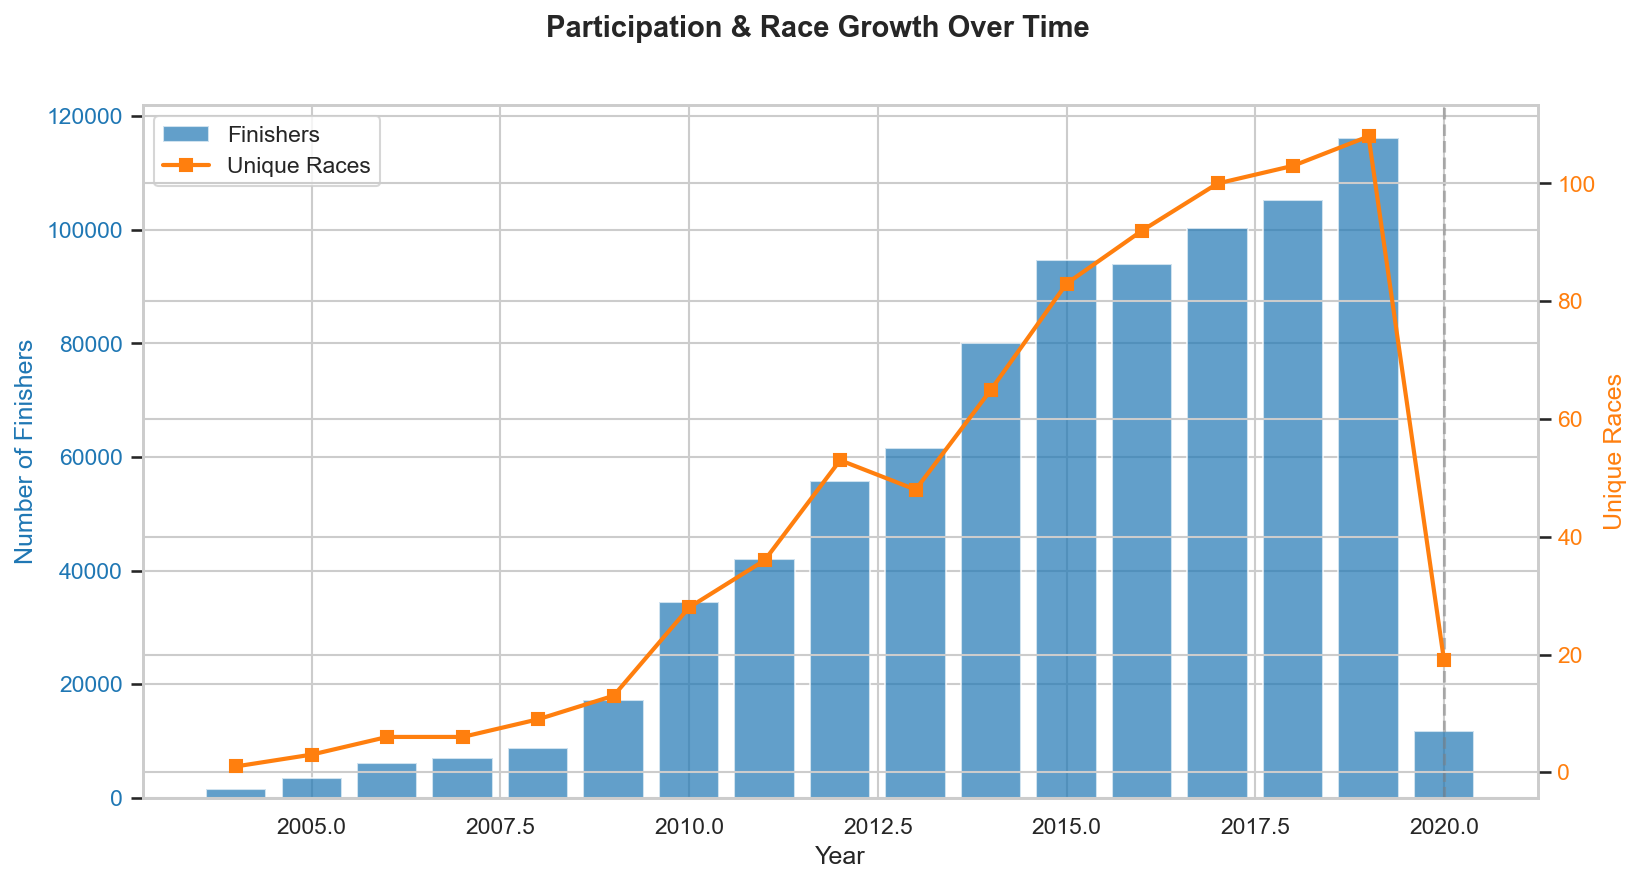

In [32]:
# 2b. Participation & race count growth
yearly_counts = df.groupby("EventYear").size().reset_index(name="Finishers")
events_per_year = df.groupby("EventYear")["EventLocation"].nunique()

fig, ax1 = plt.subplots()
ax1.bar(yearly_counts["EventYear"], yearly_counts["Finishers"], color="#1f77b4", alpha=0.7, label="Finishers")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Finishers", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

ax2 = ax1.twinx()
ax2.plot(events_per_year.index, events_per_year.values, color="#ff7f0e", marker="s", linewidth=2, label="Unique Races")
ax2.set_ylabel("Unique Races", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")

ax1.axvline(x=2020, color="gray", linestyle="--", alpha=0.5)
fig.suptitle("Participation & Race Growth Over Time", fontsize=14, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.show()


From under 1,000 finishers in the early 2000s, the sport grew to over 116,000 finishers across 60+ races by 2019. Race count and finisher numbers track together closely, suggesting growth has been supply-driven as much as demand-driven — more events created more finishers. The 2020 COVID-19 pandemic caused a near-total collapse, with finisher count falling ~90% to roughly 11,800.

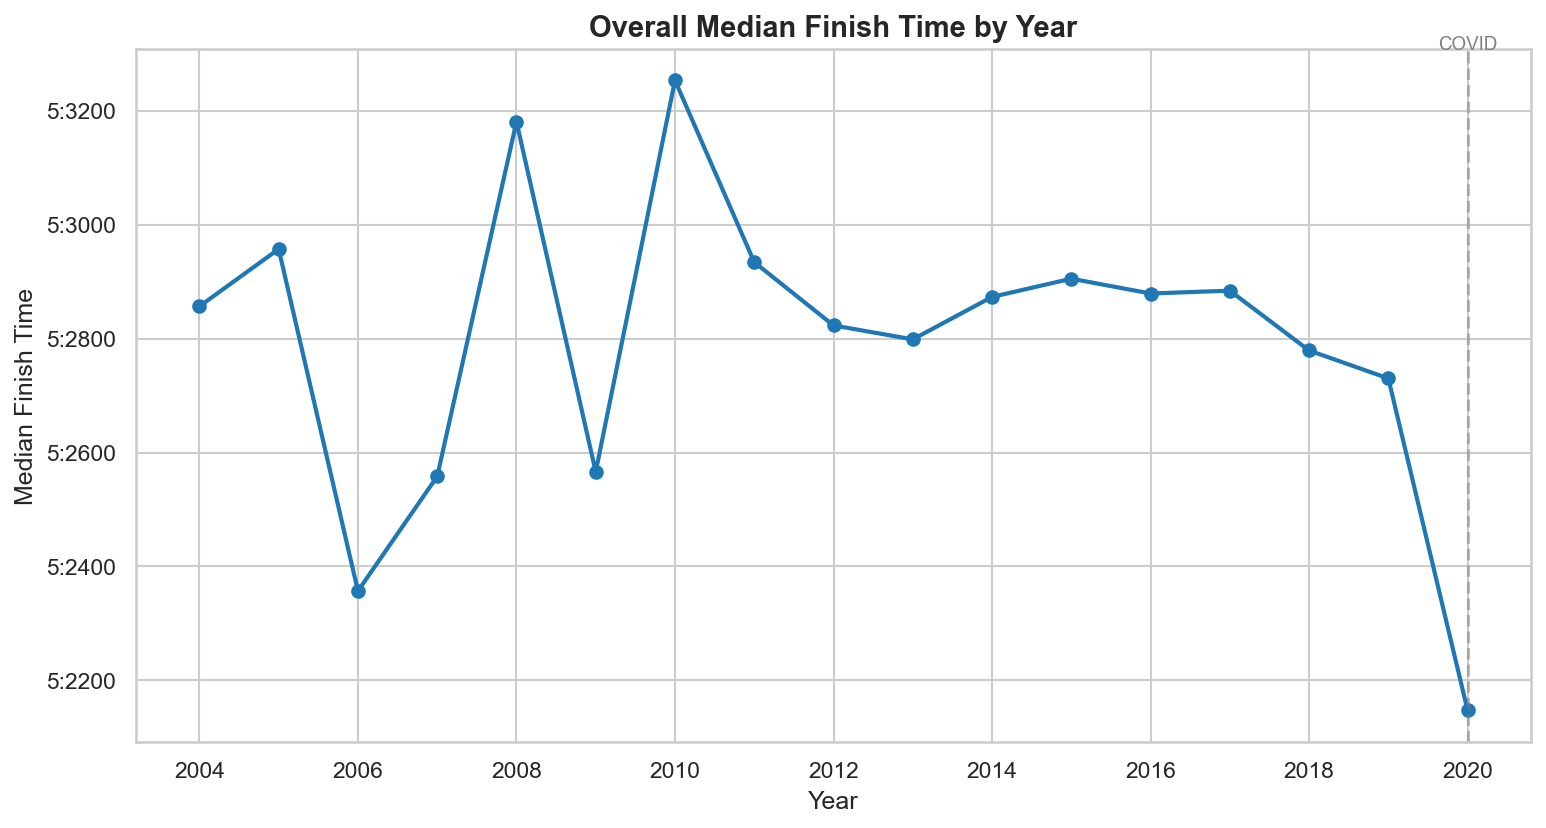

In [33]:
# 2a. Overall median finish time by year
overall_median = df.groupby("EventYear")["FinishTime"].median().reset_index()

fig, ax = plt.subplots()
ax.plot(overall_median["EventYear"], overall_median["FinishTime"], marker="o", color="#1f77b4", linewidth=2)
ax.set_title("Overall Median Finish Time by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Median Finish Time")
format_time_axis(ax, "y")
ax.axvline(x=2020, color="gray", linestyle="--", alpha=0.5)
ax.annotate("COVID", xy=(2020, ax.get_ylim()[1]), fontsize=9, color="gray", ha="center")
plt.show()

Despite the sport more than doubling in size over this period, the overall median finish time barely moved — hovering around 5h 45m–5h 50m throughout. This stability suggests that as participation grew it attracted athletes across the full spectrum of ability, keeping the median anchored rather than drifting faster or slower.

**Why median?** Finish times are right-skewed — a small number of very slow finishers pull the mean up, making it unrepresentative of a typical athlete. Median is robust to these outliers and stays consistent with the percentile-band analysis above.

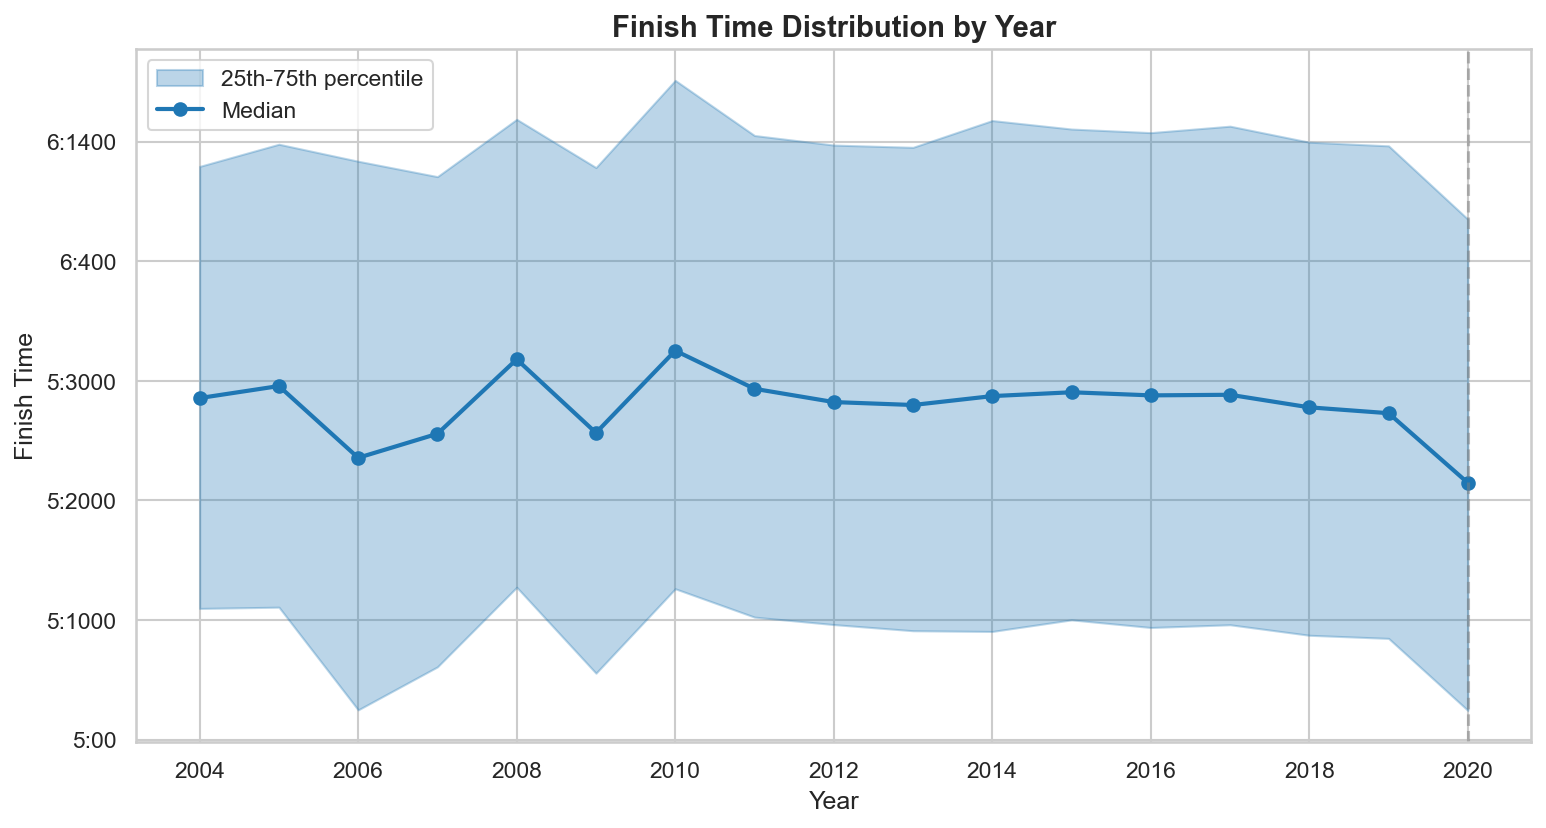

In [34]:
# 2d. Performance spread by year (percentile bands)
pctls = df.groupby("EventYear")["FinishTime"].quantile([0.25, 0.5, 0.75]).unstack().reset_index()
pctls.columns = ["EventYear", "p25", "p50", "p75"]

fig, ax = plt.subplots()
ax.fill_between(pctls["EventYear"], pctls["p25"], pctls["p75"], alpha=0.3, color="#1f77b4", label="25th-75th percentile")
ax.plot(pctls["EventYear"], pctls["p50"], color="#1f77b4", marker="o", linewidth=2, label="Median")
ax.set_title("Finish Time Distribution by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Finish Time")
format_time_axis(ax, "y")
ax.legend()
ax.axvline(x=2020, color="gray", linestyle="--", alpha=0.5)
plt.show()


The interquartile range — roughly 1 hour wide — has remained stable across the entire dataset, showing that the spread of the field hasn't changed despite explosive participation growth. Both the fast and the slow ends of the distribution moved in lockstep with the median, suggesting the sport has consistently attracted a similar mix of competitive and participation-focused athletes each year.

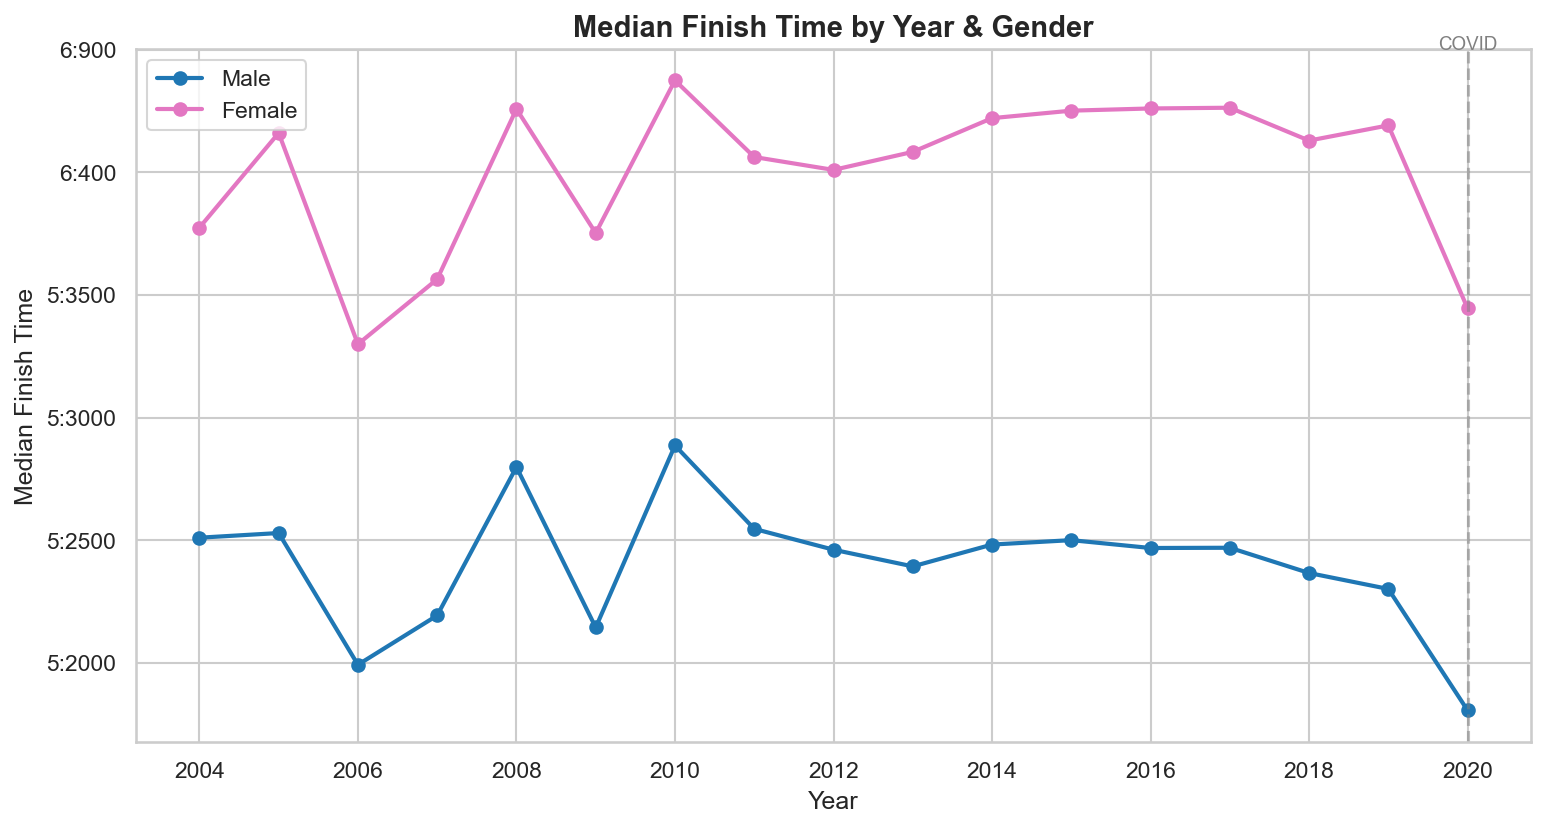

In [35]:
# 2b. Median finish time by year & gender
yearly_gender = df.groupby(["EventYear", "Gender"])["FinishTime"].median().reset_index()

fig, ax = plt.subplots()
for g, color in COLORS.items():
    subset = yearly_gender[yearly_gender["Gender"] == g]
    label = "Male" if g == "M" else "Female"
    ax.plot(subset["EventYear"], subset["FinishTime"], marker="o", color=color, label=label, linewidth=2)

ax.set_title("Median Finish Time by Year & Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Median Finish Time")
format_time_axis(ax, "y")
ax.legend()
ax.axvline(x=2020, color="gray", linestyle="--", alpha=0.5)
ax.annotate("COVID", xy=(2020, ax.get_ylim()[1]), fontsize=9, color="gray", ha="center")
plt.show()

Both genders show virtually flat median times across the full period, reinforcing that the sport's growth drew in athletes of all abilities. The gender gap — around 28–32 minutes — is consistent throughout, pointing to a stable physiological differential rather than any closing or widening trend over time.

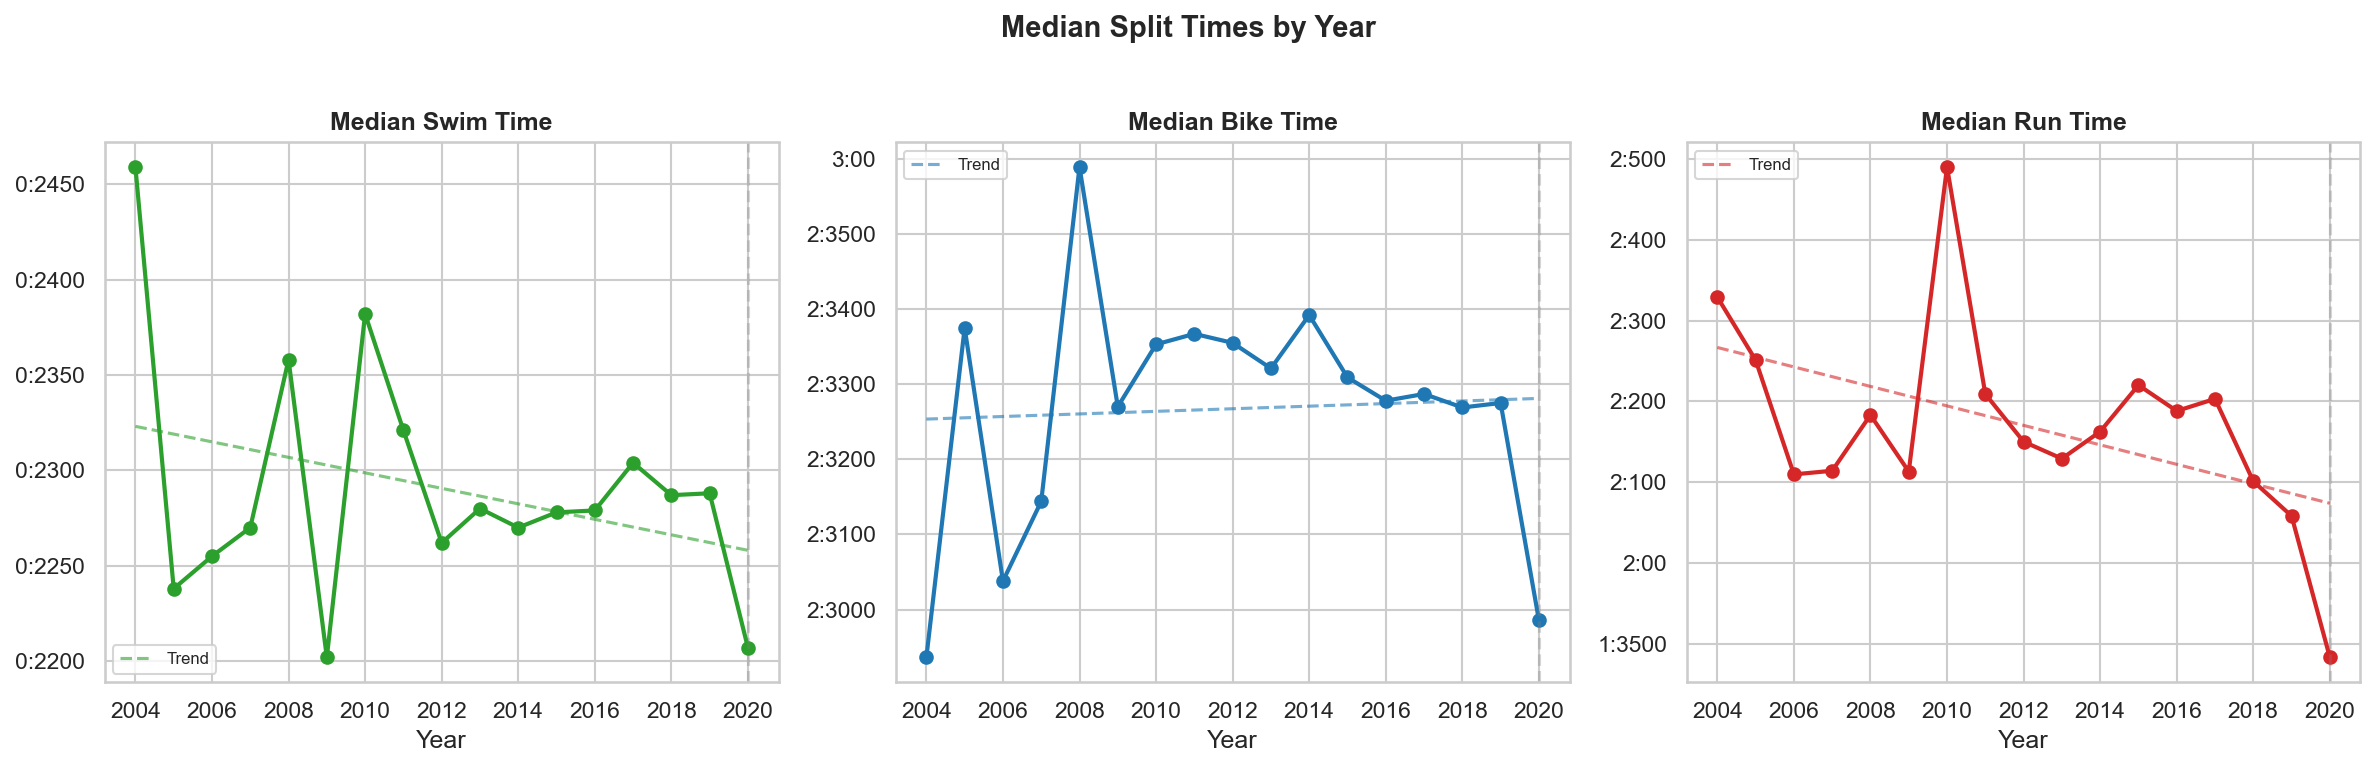

In [36]:
# 2c. Median split times by year
yearly_splits = df.groupby("EventYear")[["SwimTime", "BikeTime", "RunTime"]].median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, col, title, color in zip(axes, ["SwimTime", "BikeTime", "RunTime"],
                                       ["Swim", "Bike", "Run"],
                                       ["#2ca02c", "#1f77b4", "#d62728"]):
    x_vals = yearly_splits["EventYear"].values
    y_vals = yearly_splits[col].values
    ax.plot(x_vals, y_vals, marker="o", color=color, linewidth=2)
    # Linear trend line
    z = np.polyfit(x_vals, y_vals, 1)
    ax.plot(x_vals, np.poly1d(z)(x_vals), color=color, linestyle="--", linewidth=1.5, alpha=0.6, label="Trend")
    ax.set_title(f"Median {title} Time", fontweight="bold")
    ax.set_xlabel("Year")
    format_time_axis(ax, "y")
    ax.axvline(x=2020, color="gray", linestyle="--", alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Median Split Times by Year", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Swim and bike times are remarkably flat across the period. The run shows a marginal upward trend (slower), which may reflect the sport's growth drawing in athletes who are stronger swimmers or cyclists but less running-focused. All three disciplines dip noticeably in 2020, likely because the small number of races held that year attracted a disproportionate share of competitive, experienced athletes.

---
## 3. Age Group Analysis


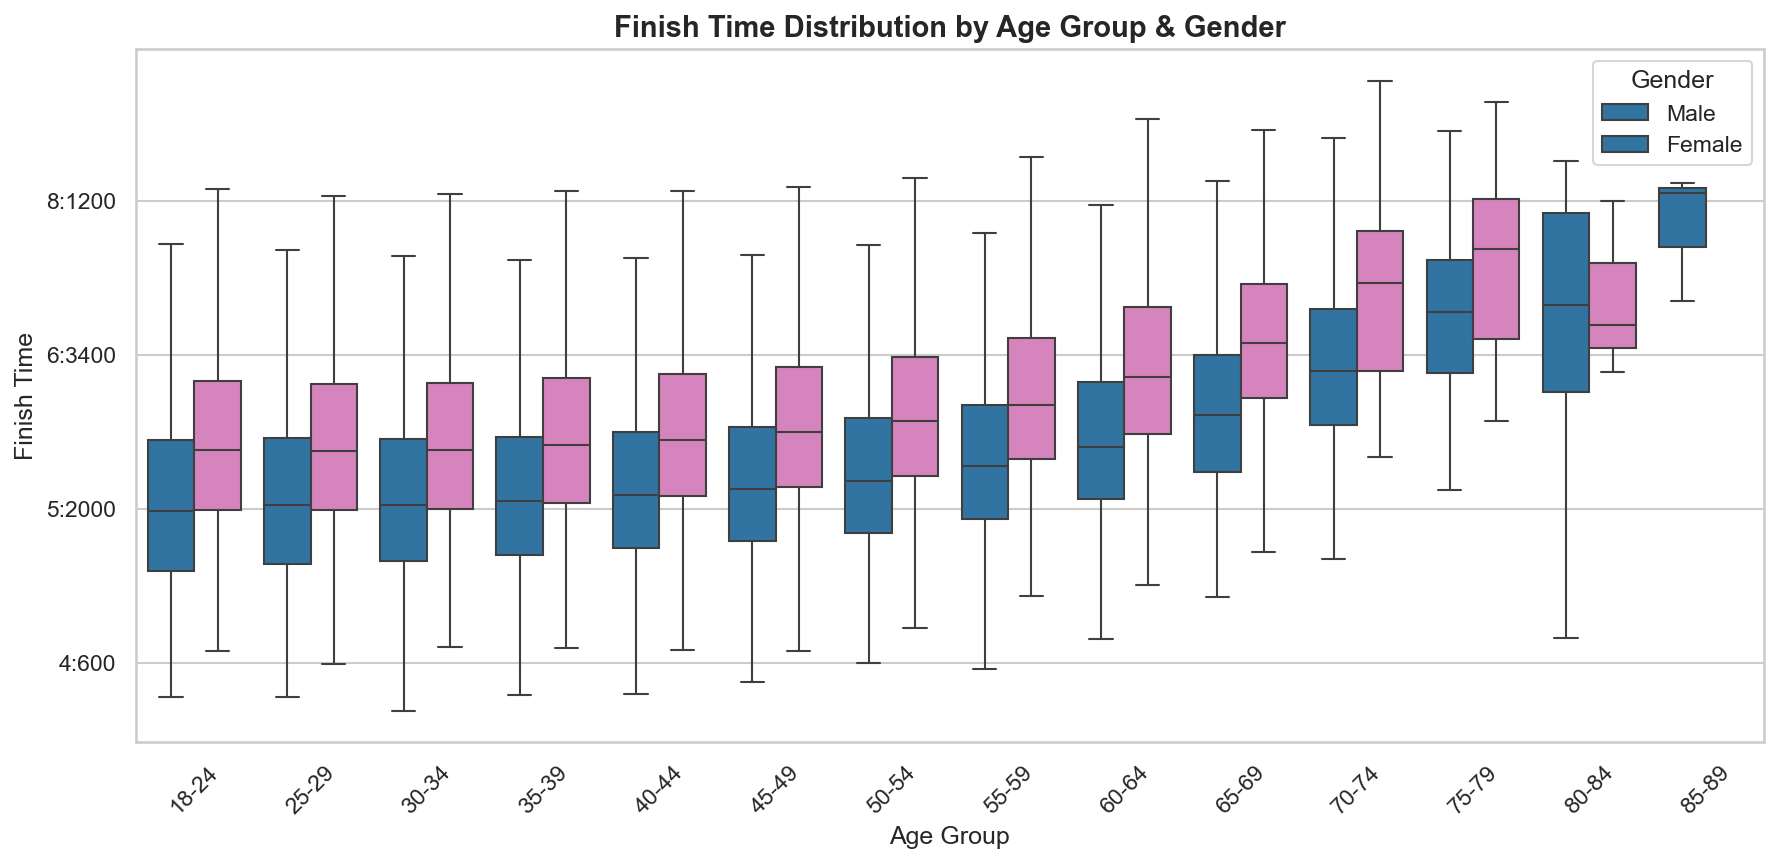

In [37]:
# 4a. Finish time distribution by age group & gender (boxplot)
age_df = df[df["AgeGroup"].isin(standard_ages)].copy()
age_df["AgeGroup"] = pd.Categorical(age_df["AgeGroup"], categories=standard_ages, ordered=True)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=age_df, x="AgeGroup", y="FinishTime", hue="Gender",
            palette=COLORS, showfliers=False, ax=ax)
ax.set_title("Finish Time Distribution by Age Group & Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Finish Time")
format_time_axis(ax, "y")
ax.legend(title="Gender", labels=["Male", "Female"])
plt.xticks(rotation=45)
plt.show()


The 25–34 age bands post the tightest distributions and fastest medians for both genders. Performance degrades gradually through the 40s and then more steeply from 55 onwards. Women's medians sit consistently 25–35 minutes above men's across all age groups, but the shape of the curve is nearly identical — age affects both genders in the same way.

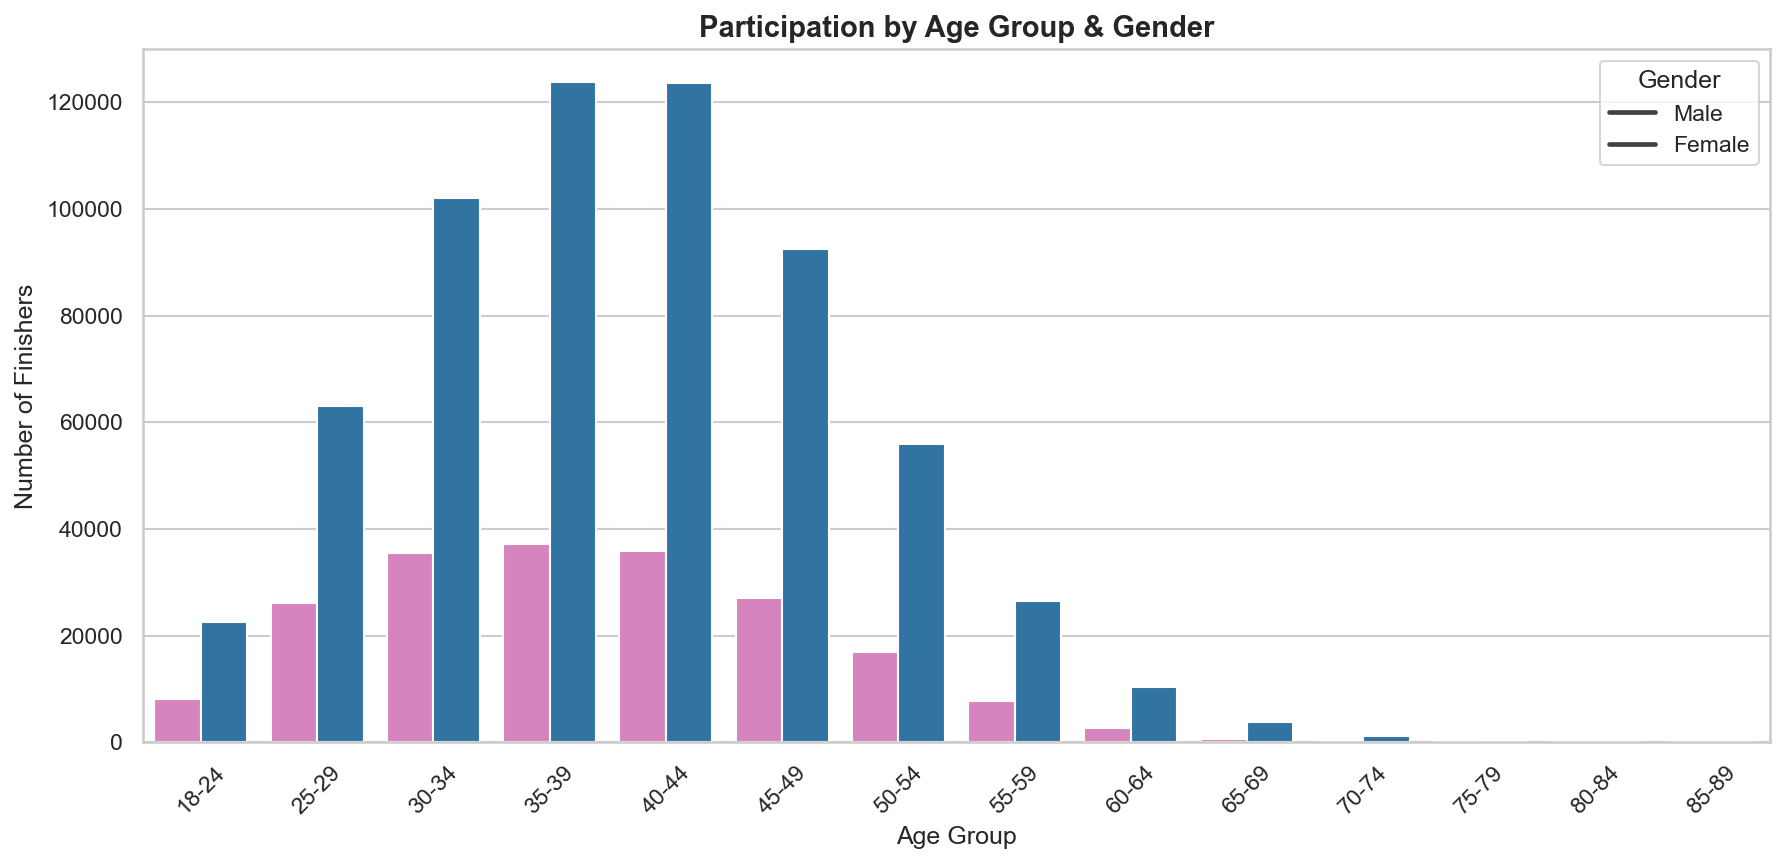

In [38]:
# 4b. Participation by age group & gender
age_counts = age_df.groupby(["AgeGroup", "Gender"], observed=False).size().reset_index(name="Count")

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=age_counts, x="AgeGroup", y="Count", hue="Gender", palette=COLORS, ax=ax)
ax.set_title("Participation by Age Group & Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Finishers")
ax.legend(title="Gender", labels=["Male", "Female"])
plt.xticks(rotation=45)
plt.show()


The 35–44 age band accounts for the largest share of finishers — a group with the disposable income and life structure to support training for a long-distance triathlon. Female participation is lower across every age group, with the ratio most balanced in the 25–34 range. Note that raw counts are shown here; per-capita or proportional views would adjust for the uneven age group sizes.

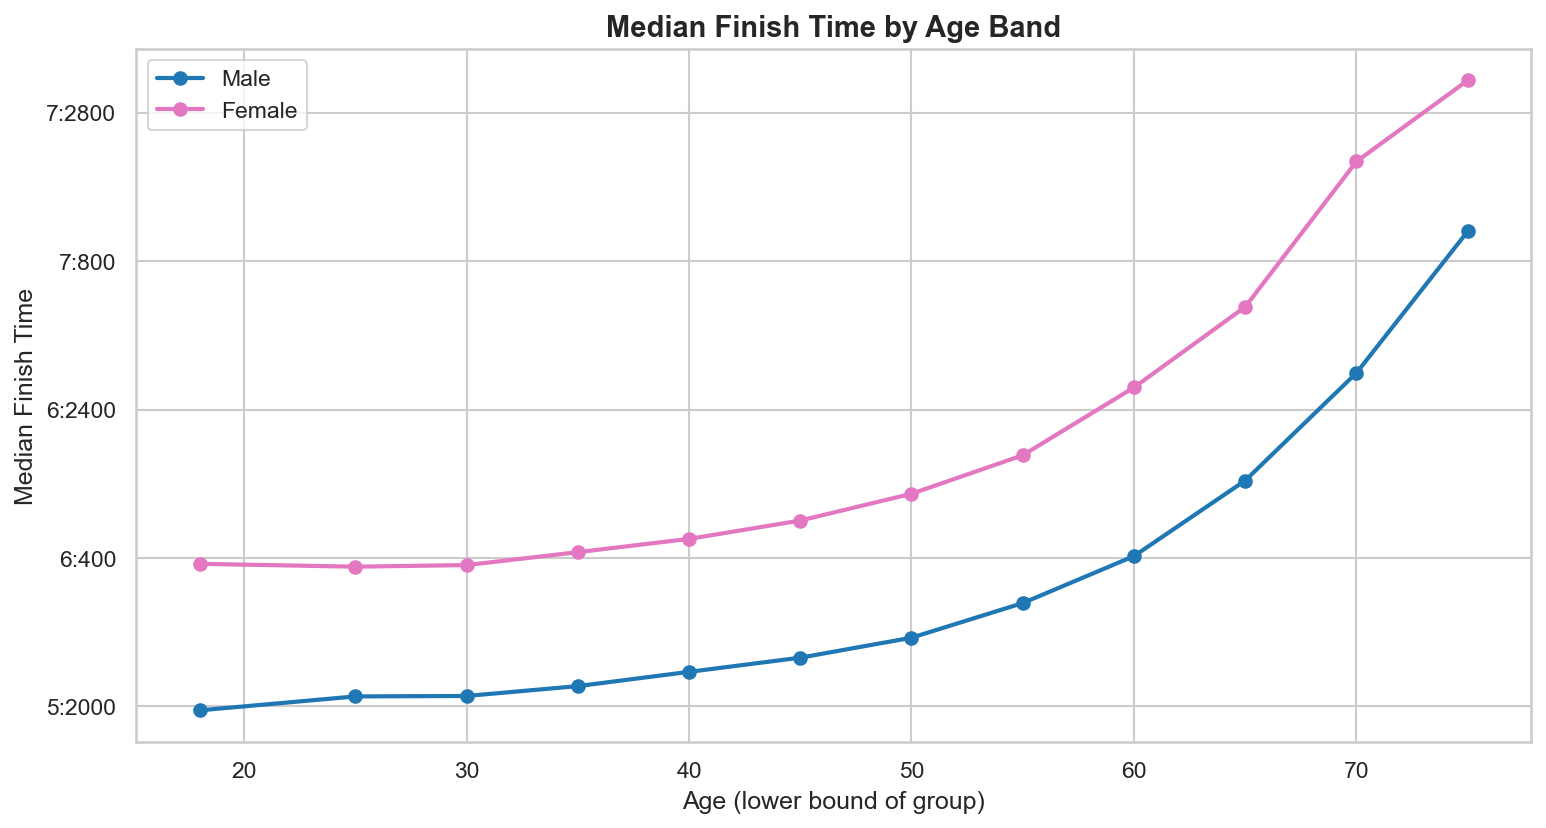

In [39]:
# 4c. Peak performance: median finish by age band
peak = df.groupby(["AgeBand", "Gender"])["FinishTime"].median().reset_index()
peak = peak[peak["AgeBand"].between(18, 75)]

fig, ax = plt.subplots()
for g, color in COLORS.items():
    subset = peak[peak["Gender"] == g]
    label = "Male" if g == "M" else "Female"
    ax.plot(subset["AgeBand"], subset["FinishTime"], marker="o", color=color, label=label, linewidth=2)

ax.set_title("Median Finish Time by Age Band", fontsize=14, fontweight="bold")
ax.set_xlabel("Age (lower bound of group)")
ax.set_ylabel("Median Finish Time")
format_time_axis(ax, "y")
ax.legend()
plt.show()


Both men and women peak in the late 20s to early 30s. The decline through the 30s and 40s is notably gentle — athletes in their mid-40s are typically only 15–20 minutes slower than their peak — before performance drops more sharply after 55. This gradual ageing curve is one reason the sport attracts and retains a strong Masters demographic.

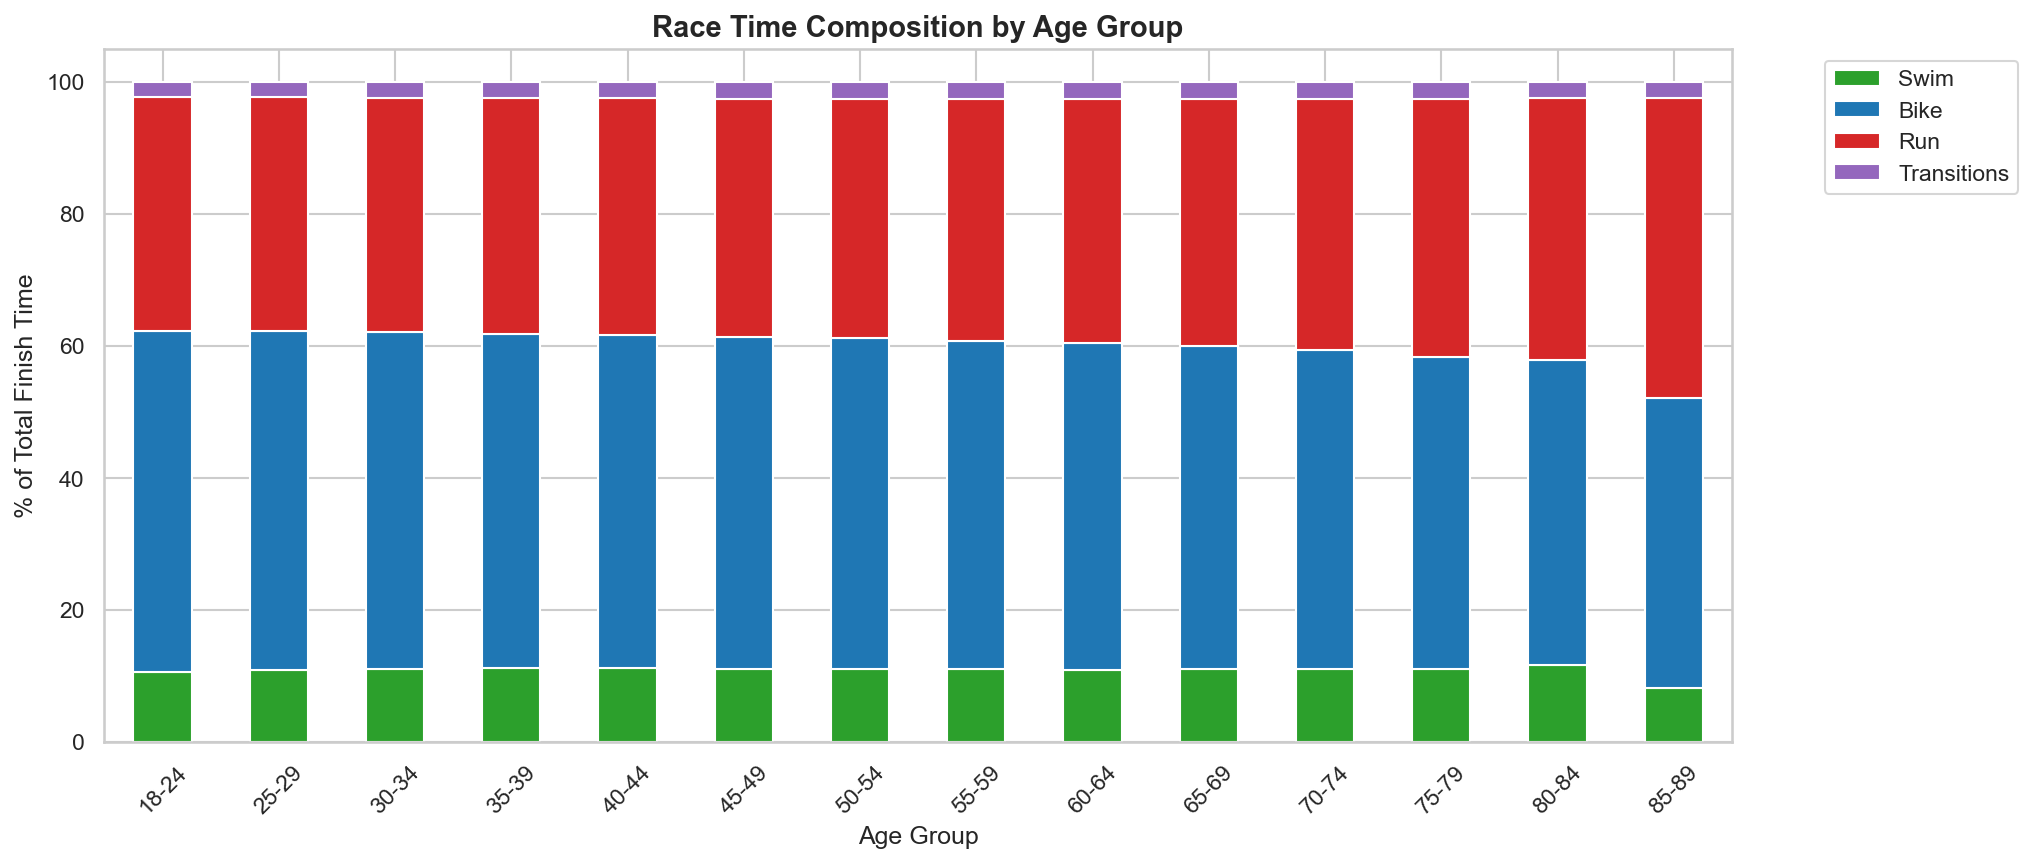

In [40]:
# 4d. Race time composition by age group (stacked bar)
split_pct = age_df.groupby("AgeGroup", observed=False)[["SwimPct", "BikePct", "RunPct", "TransitionPct"]].mean()

fig, ax = plt.subplots(figsize=(14, 6))
split_pct[["SwimPct", "BikePct", "RunPct", "TransitionPct"]].plot.bar(
    stacked=True, ax=ax, color=["#2ca02c", "#1f77b4", "#d62728", "#9467bd"]
)
ax.set_title("Race Time Composition by Age Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("% of Total Finish Time")
ax.legend(["Swim", "Bike", "Run", "Transitions"], bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.show()


The bike leg consistently accounts for roughly 50% of total finish time across every age group, with swim at ~14% and run at ~25%. The run proportion increases slightly in older groups, suggesting running pace deteriorates faster with age than swimming or cycling. Transitions contribute a small but measurable ~2–3%, a reminder that T1/T2 efficiency is a real differentiator at all ages.

---
## 4. Country Comparisons


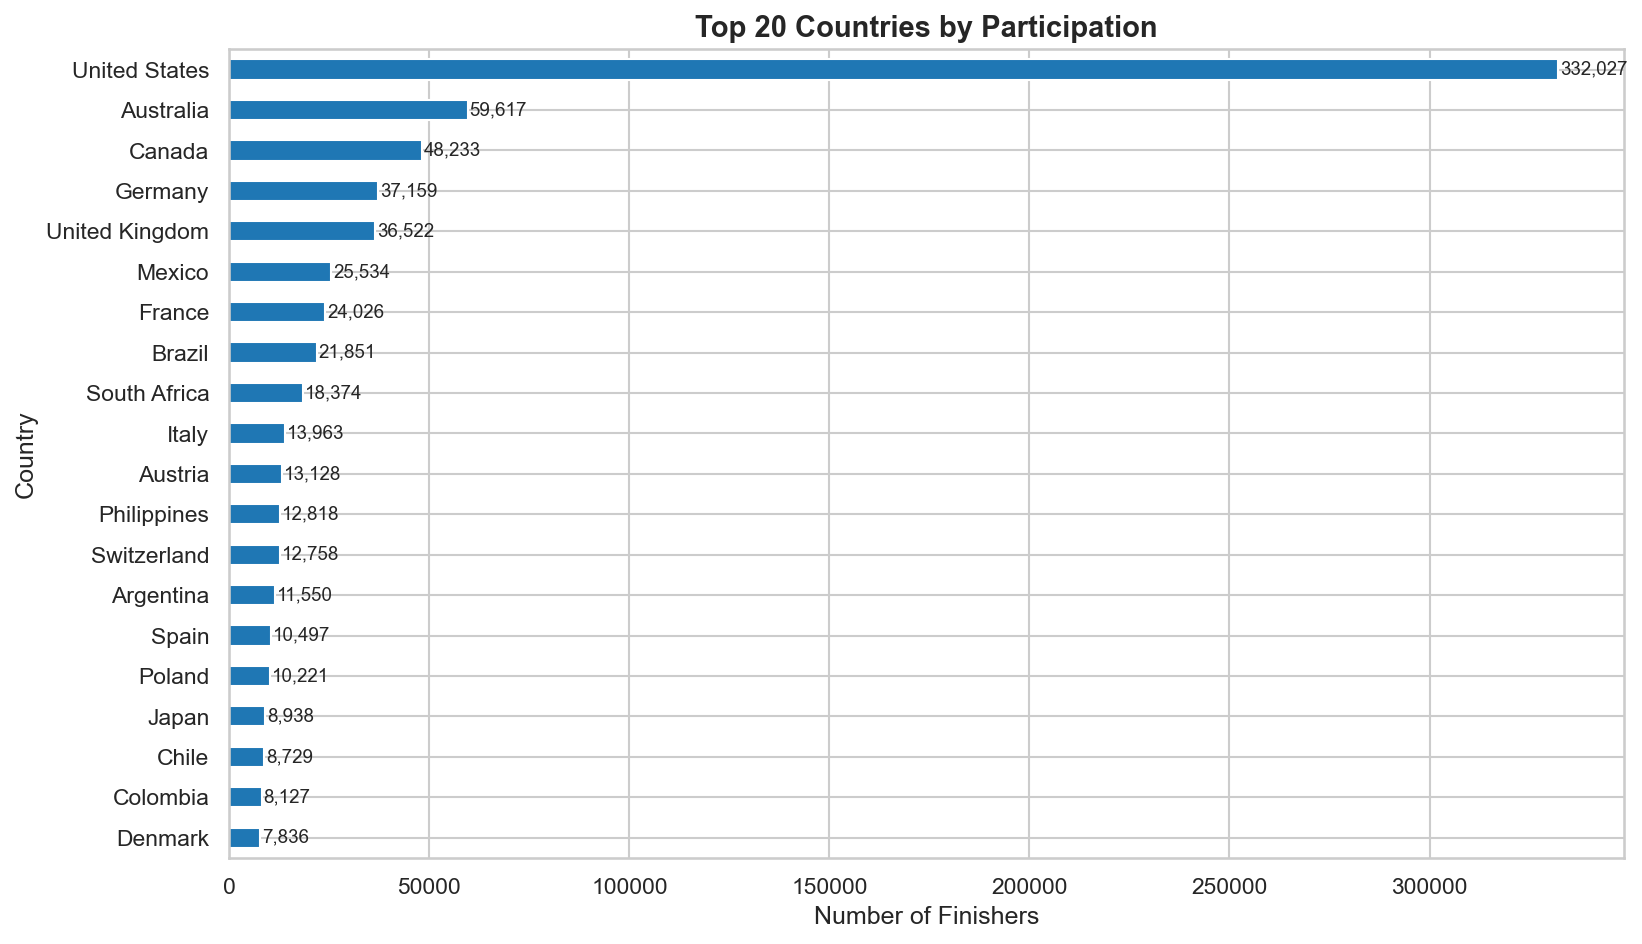

In [41]:
# 3a. Top 20 countries by participation
country_counts = df["Country"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
country_counts.plot.barh(ax=ax, color="#1f77b4")
ax.invert_yaxis()
ax.set_title("Top 20 Countries by Participation", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Finishers")
for i, v in enumerate(country_counts):
    ax.text(v + 500, i, f"{v:,}", va="center", fontsize=9)
plt.show()


The USA contributes more finishers than the next several countries combined, reflecting both the sport's North American origins and the sheer density of IRONMAN events hosted there. Australia and Germany are distant second and third, followed by a cluster of European nations with strong triathlon cultures. The long tail of countries highlights the sport's increasingly global footprint.

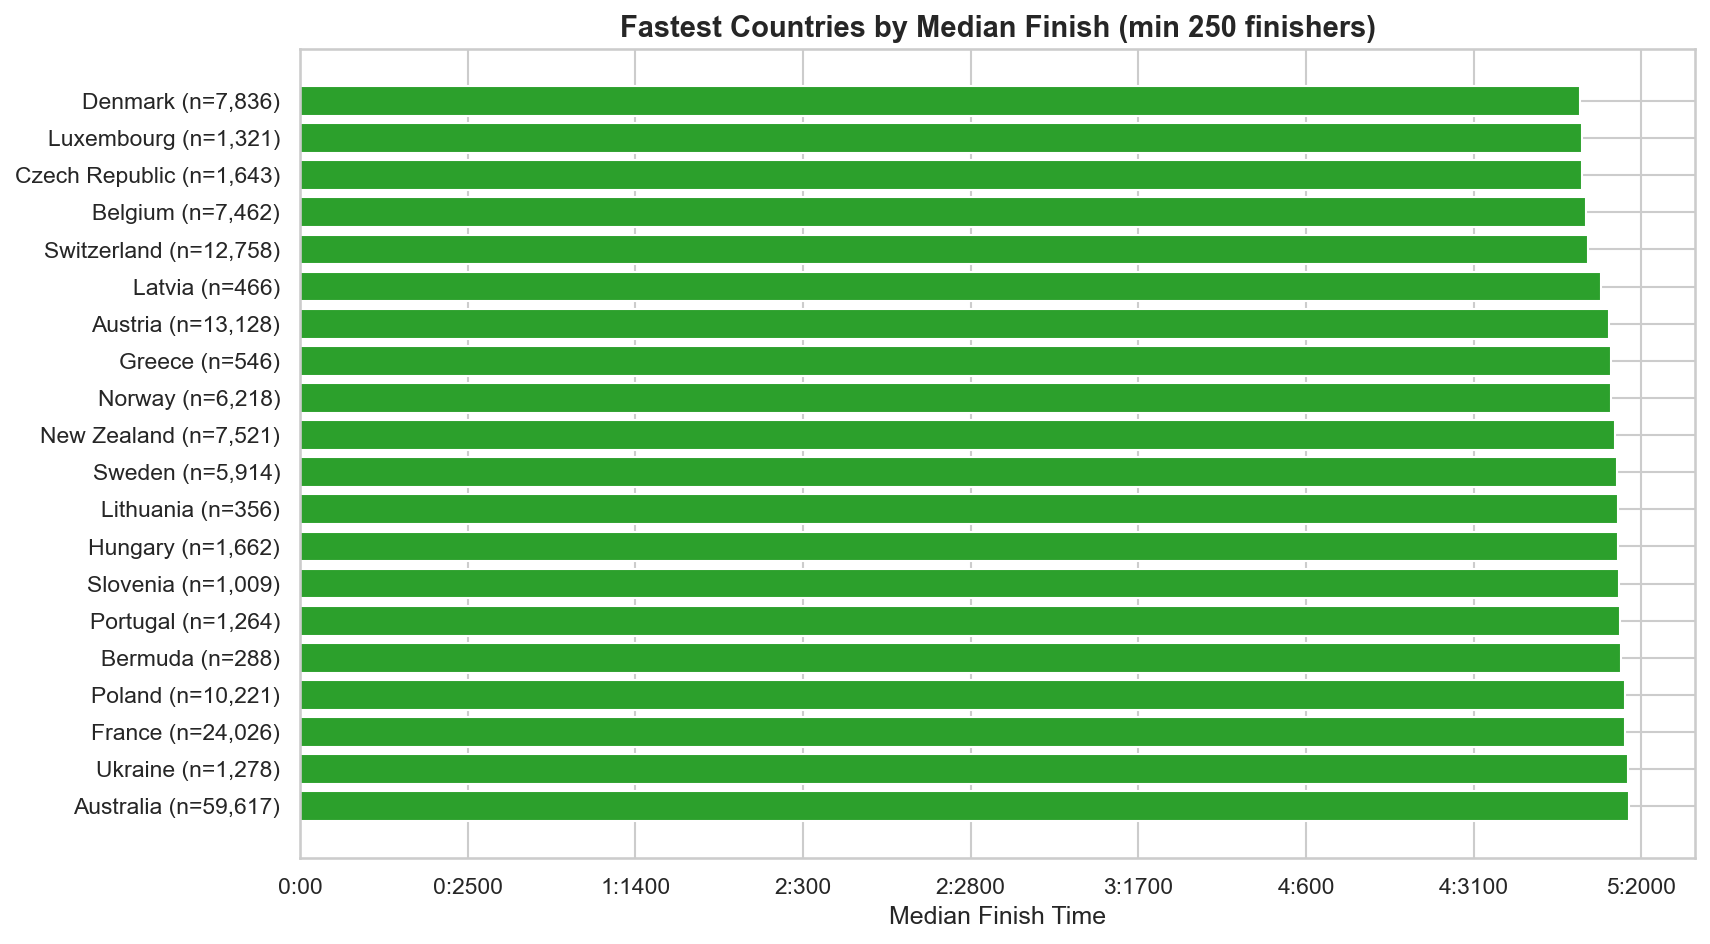

In [42]:
# 3b. Fastest countries (min 250 finishers)
MIN_COUNTRY = 250
country_perf = df.groupby("Country").agg(
    median_finish=("FinishTime", "median"),
    count=("FinishTime", "size")
).query(f"count >= {MIN_COUNTRY}").sort_values("median_finish")

top20_fast = country_perf.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(top20_fast)), top20_fast["median_finish"], color="#2ca02c")
ax.set_yticks(range(len(top20_fast)))
ax.set_yticklabels([f"{c} (n={int(top20_fast.loc[c, 'count']):,})" for c in top20_fast.index])
ax.invert_yaxis()
ax.set_title(f"Fastest Countries by Median Finish (min {MIN_COUNTRY} finishers)", fontsize=14, fontweight="bold")
format_time_axis(ax, "x")
ax.set_xlabel("Median Finish Time")
plt.show()


European nations with deep triathlon and cycling cultures — Switzerland, Germany, Belgium — dominate the top of the speed leaderboard. The 250-finisher threshold filters out countries with tiny sample sizes, so these rankings reflect genuine population-level speed rather than a handful of elite athletes. Notably, high-participation countries like the USA sit further down, suggesting volume and speed don't necessarily go hand in hand.

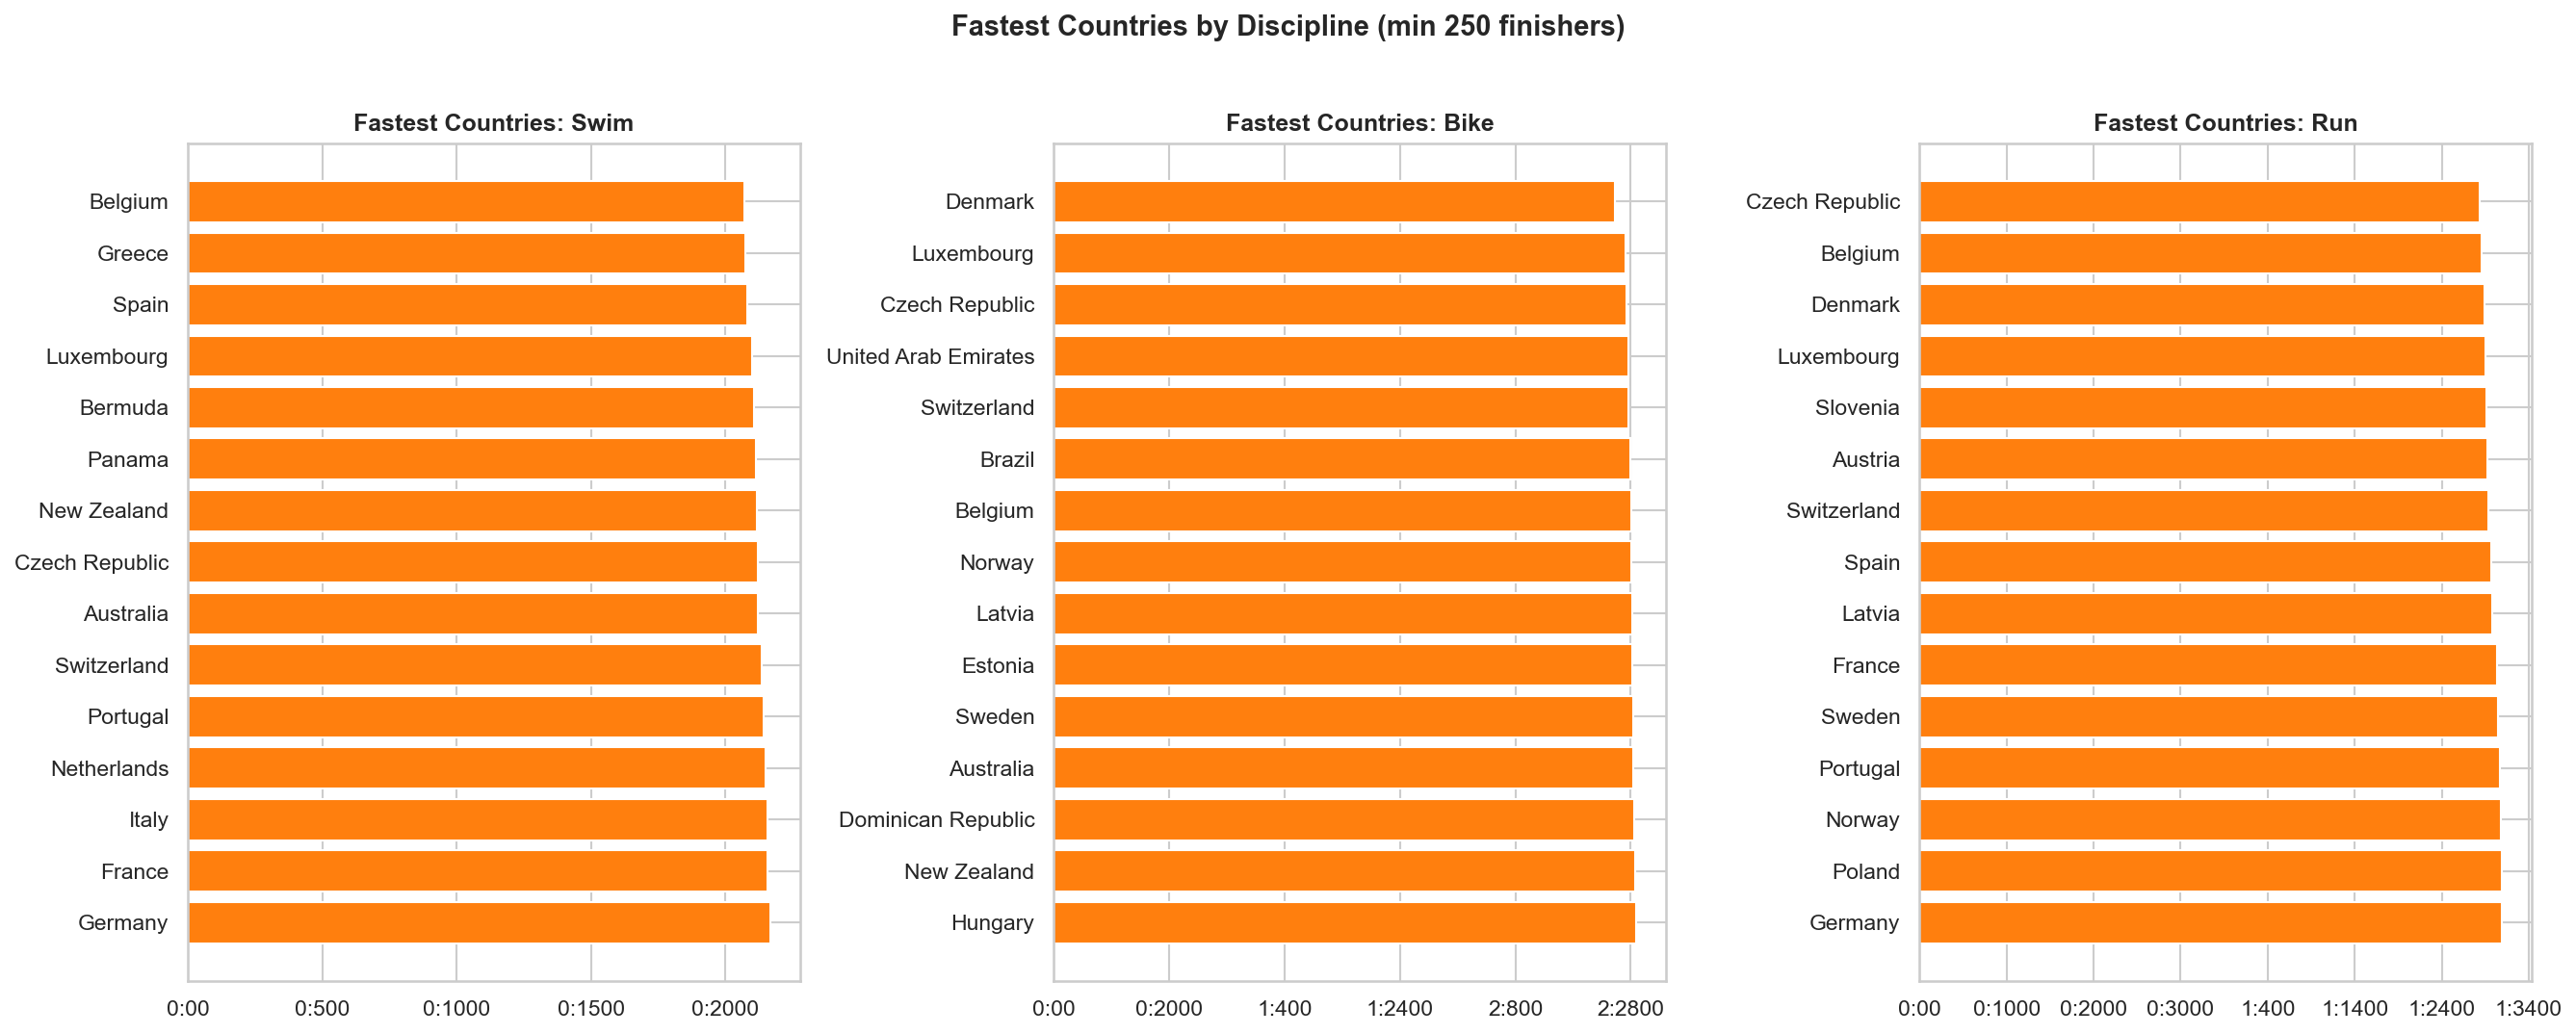

In [43]:
# 3c. Fastest countries by discipline
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, col, title in zip(axes, ["SwimTime", "BikeTime", "RunTime"], ["Swim", "Bike", "Run"]):
    disc = df.groupby("Country").agg(
        median_time=(col, "median"), count=(col, "size")
    ).query(f"count >= {MIN_COUNTRY}").sort_values("median_time").head(15)
    ax.barh(range(len(disc)), disc["median_time"], color="#ff7f0e")
    ax.set_yticks(range(len(disc)))
    ax.set_yticklabels(disc.index)
    ax.invert_yaxis()
    ax.set_title(f"Fastest Countries: {title}", fontweight="bold")
    format_time_axis(ax, "x")

plt.suptitle(f"Fastest Countries by Discipline (min {MIN_COUNTRY} finishers)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


Discipline leadership varies considerably across swim, bike, and run, revealing distinct national strengths. Countries that top the swim rankings don't always appear in the bike or run lists — pointing to different sporting traditions and training cultures. The bike leaderboard most closely mirrors the overall finish time ranking, consistent with the bike leg's ~50% share of total race time.

---
## 5. Race / Course Comparisons


In [44]:
# Helper to shorten race names
def shorten_name(name):
    return name.replace("IRONMAN 70.3 ", "").replace("IRONMAN ", "")

MIN_RACE = 100
race_stats = df.groupby("EventLocation").agg(
    median_finish=("FinishTime", "median"),
    count=("FinishTime", "size"),
    years=("EventYear", "nunique")
).query(f"count >= {MIN_RACE}")

print(f"Races with >= {MIN_RACE} finishers: {len(race_stats)}")


Races with >= 100 finishers: 194


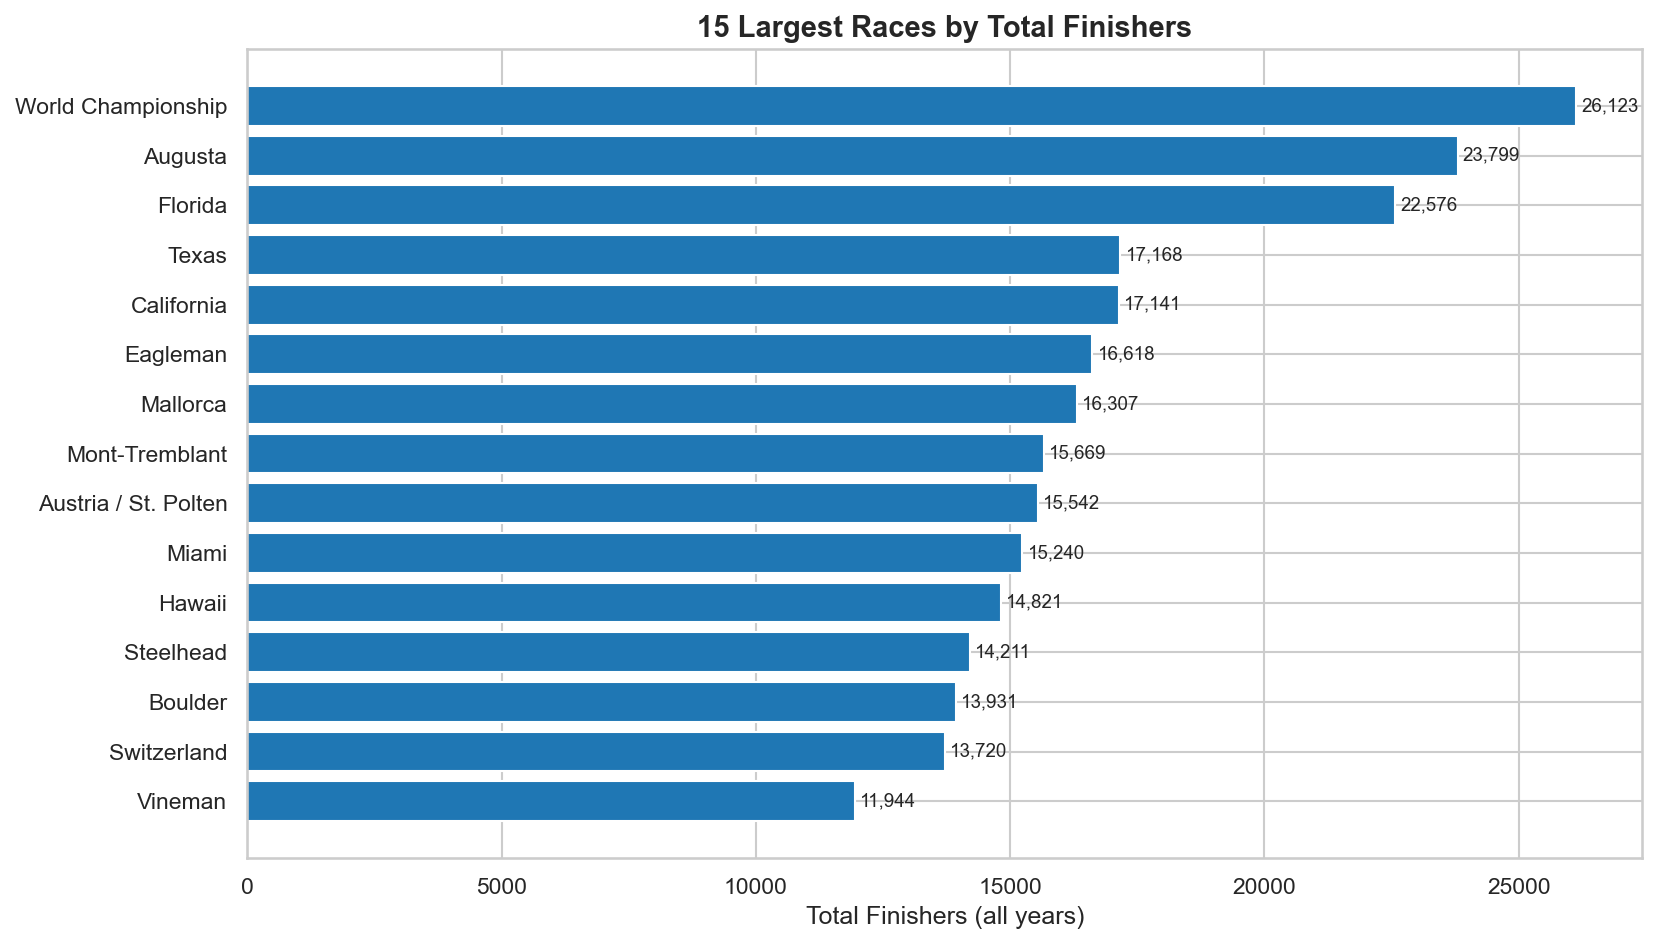

In [45]:
# 5c. Largest races by total participation
largest = race_stats.sort_values("count", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(largest)), largest["count"], color="#1f77b4")
ax.set_yticks(range(len(largest)))
ax.set_yticklabels([shorten_name(c) for c in largest.index])
ax.invert_yaxis()
ax.set_title("15 Largest Races by Total Finishers", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Finishers (all years)")
for i, v in enumerate(largest["count"]):
    ax.text(v + 100, i, f"{int(v):,}", va="center", fontsize=9)
plt.show()


Volume reflects longevity as much as field size — events that have run for many years accumulate finishers across multiple editions. US races dominate the top, consistent with the country's participation numbers. Several World Championship qualifier venues appear here, drawing competitors from across the globe year after year.

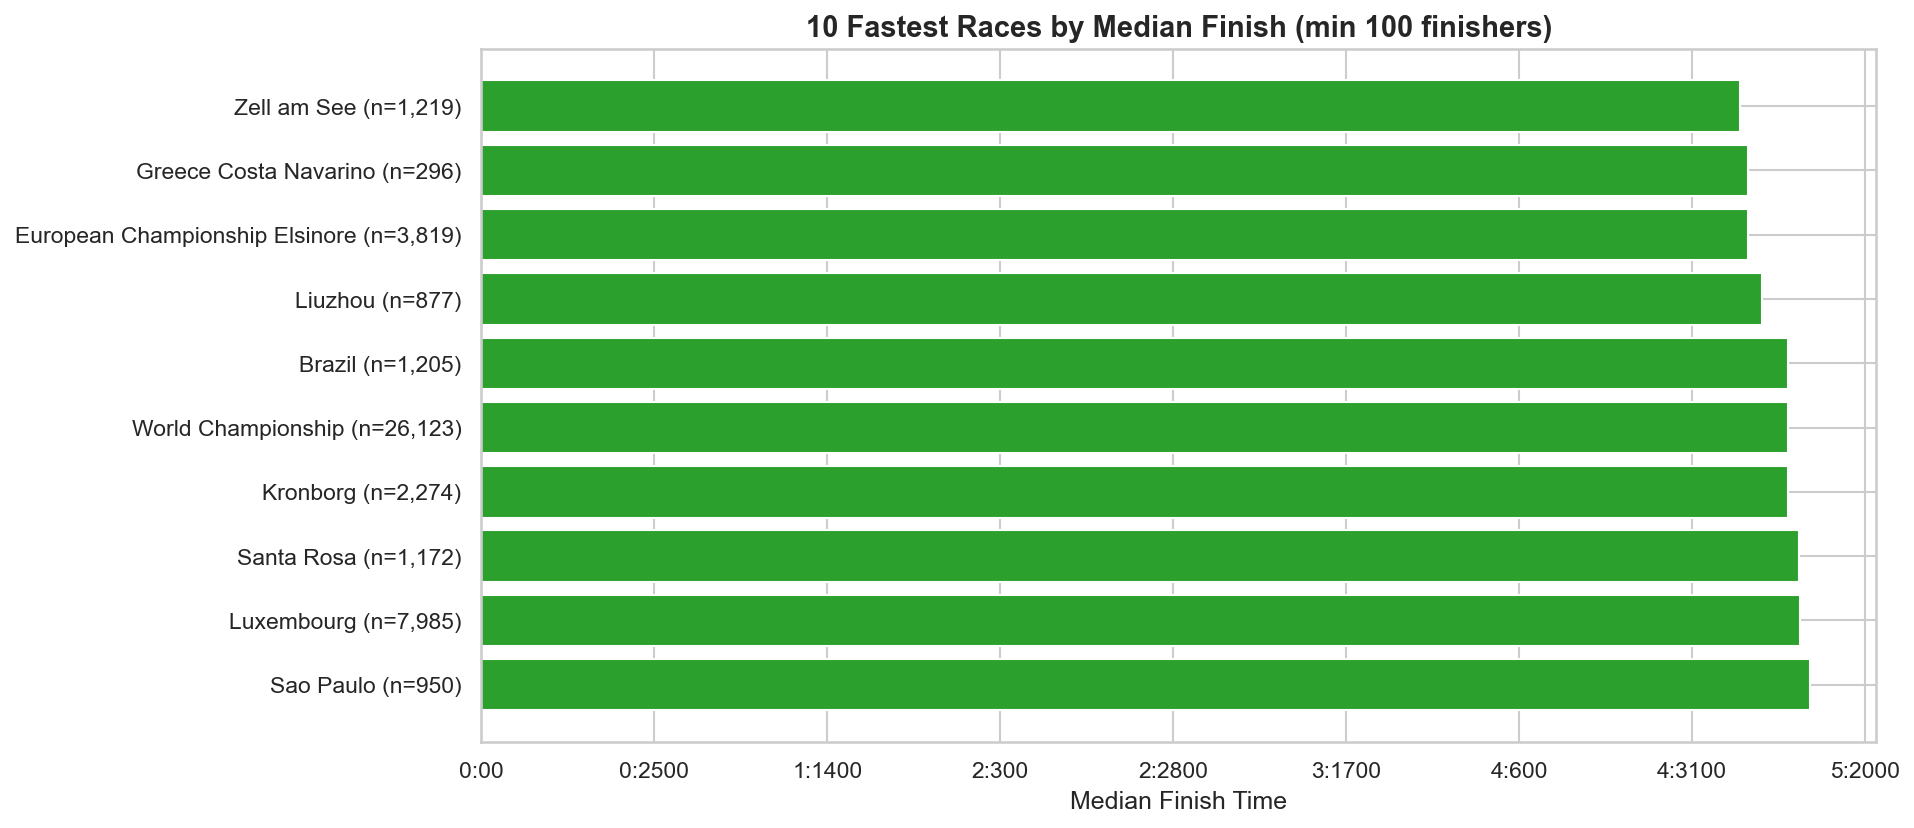

In [46]:
# 5a. Top 10 fastest races
fastest = race_stats.sort_values("median_finish").head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(fastest)), fastest["median_finish"], color="#2ca02c")
ax.set_yticks(range(len(fastest)))
ax.set_yticklabels([f"{shorten_name(c)} (n={int(fastest.loc[c, 'count']):,})" for c in fastest.index])
ax.invert_yaxis()
ax.set_title(f"10 Fastest Races by Median Finish (min {MIN_RACE} finishers)", fontsize=14, fontweight="bold")
format_time_axis(ax, "x")
ax.set_xlabel("Median Finish Time")
plt.show()


Flat, low-elevation courses in mild climates dominate the fast end of the list. These races are typically prestigious qualifier events that attract more competitive, experienced athletes — which itself pulls the median down. Course selection is therefore one of the most reliable levers an athlete can pull to post a personal best.

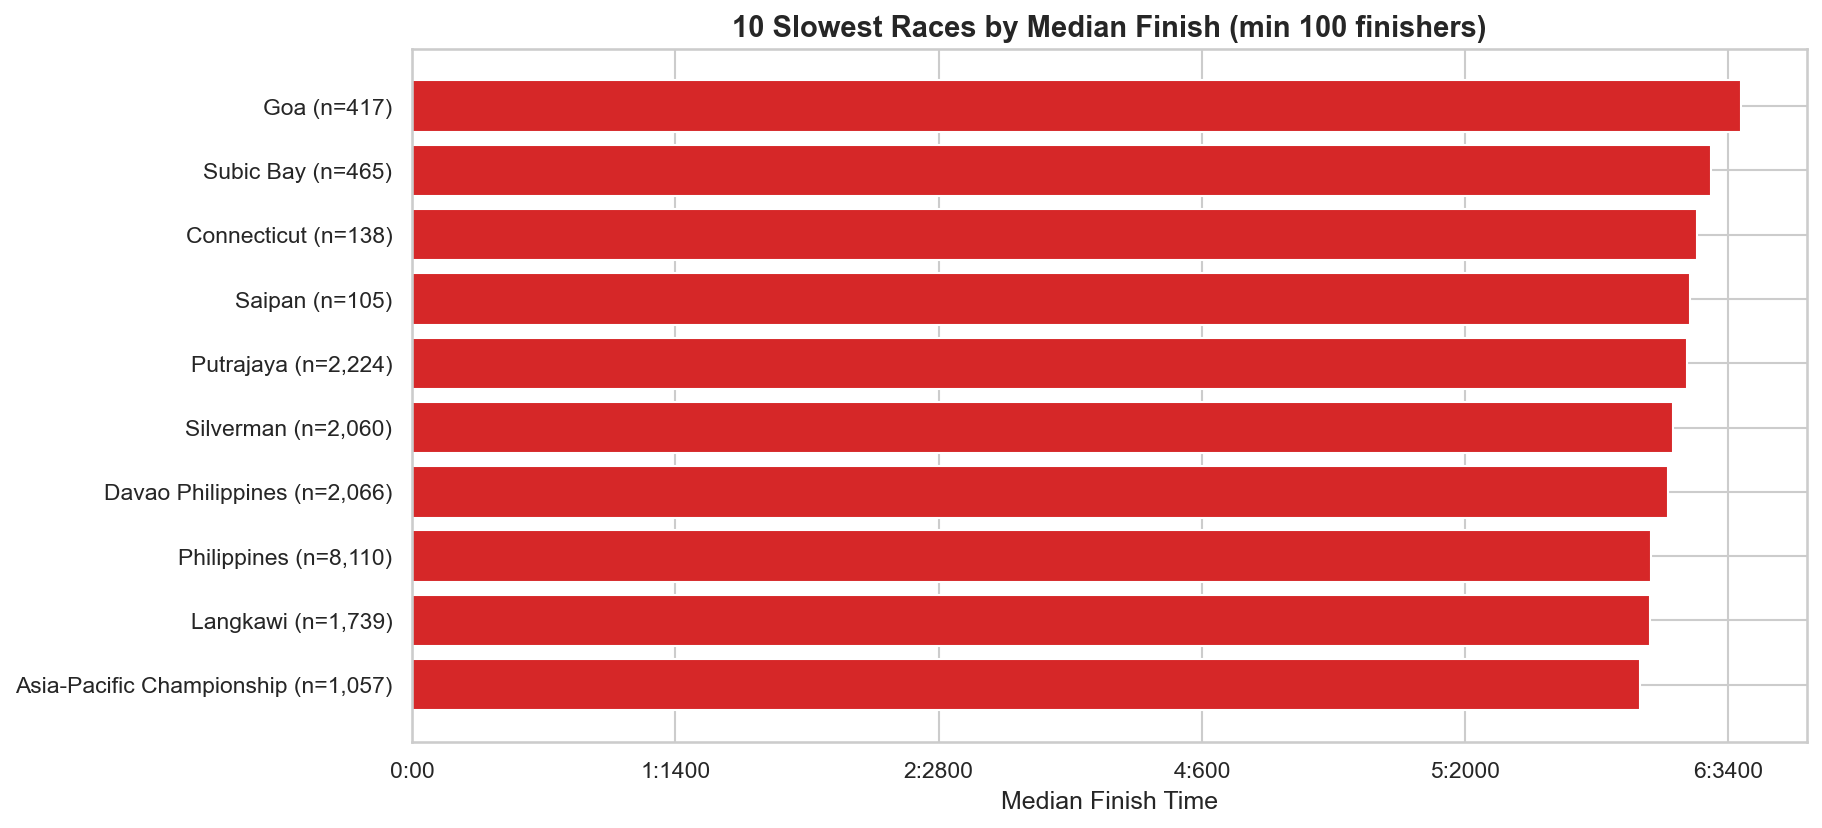

In [47]:
# 5b. Top 10 slowest races
slowest = race_stats.sort_values("median_finish", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(slowest)), slowest["median_finish"], color="#d62728")
ax.set_yticks(range(len(slowest)))
ax.set_yticklabels([f"{shorten_name(c)} (n={int(slowest.loc[c, 'count']):,})" for c in slowest.index])
ax.invert_yaxis()
ax.set_title(f"10 Slowest Races by Median Finish (min {MIN_RACE} finishers)", fontsize=14, fontweight="bold")
format_time_axis(ax, "x")
ax.set_xlabel("Median Finish Time")
plt.show()


Mountainous terrain and technically demanding courses push medians well above average — some exceed 6h 30m. A few of the slowest races are also newer or smaller events whose fields skew toward first-timers and participation-focused athletes rather than seasoned competitors. Course difficulty and field composition both contribute to slower medians.

---
## 6. Gender Analysis


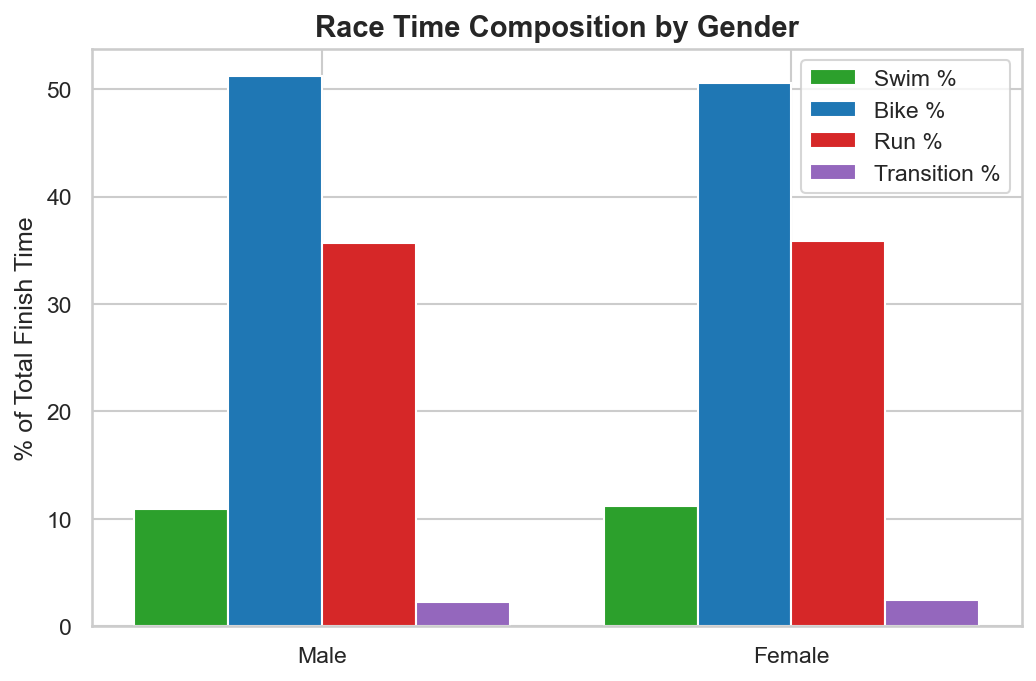

In [48]:
# 6d. Race time composition by gender
gender_splits = df.groupby("Gender")[["SwimPct", "BikePct", "RunPct", "TransitionPct"]].mean()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(gender_splits.index))
width = 0.2
labels = ["Swim %", "Bike %", "Run %", "Transition %"]
colors = ["#2ca02c", "#1f77b4", "#d62728", "#9467bd"]
for i, (col, label, color) in enumerate(zip(gender_splits.columns, labels, colors)):
    ax.bar(x + i * width, gender_splits[col], width, label=label, color=color)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(["Male", "Female"])
ax.set_title("Race Time Composition by Gender", fontsize=14, fontweight="bold")
ax.set_ylabel("% of Total Finish Time")
ax.legend()
plt.show()


Men and women allocate race time across disciplines in almost identical proportions — bike at ~50%, run at ~25%, swim at ~14%, and transitions at ~2–3% for both. The near-identical split profile suggests that pacing and race strategy, rather than any structural gender difference, drives how athletes distribute their effort across the three disciplines.

---
## Key Findings

- **Median finish time**: 5h 47m overall (Male: 5h 40m, Female: 6h 09m)
- **Performance is stable** across years — median times have barely changed 2004–2019
- **Peak age group**: 18-24 has fastest median, but performance holds well through 45-49
- **US dominates** participation (332K finishers, 5.5x more than #2 Australia)
- **Female participation** has grown steadily, reaching ~25% by 2019
- **2020 COVID impact**: only 11.8K finishers vs 116K in 2019
- **Bike leg** accounts for ~50% of total race time across all groups
